# 06 · Evaluación — Explicabilidad con SHAP (comparación de los 3 modelos)

La importancia de variables dice *cuánto* pesa cada variable, pero no *en qué
dirección* ni *para quién*. **SHAP** (SHapley Additive exPlanations) responde eso, y
aquí lo usamos para **comparar cómo explica cada modelo** — XGBoost, Random Forest y
LogReg. Que los tres coincidan en la *dirección* y *forma* de los efectos clave es
una señal fuerte de que el modelo aprende algo real del negocio, no un artefacto.

## Idea teórica

SHAP viene de la **teoría de juegos cooperativos**: trata cada predicción como un
"premio" que se reparte de forma justa entre las variables (los "jugadores"). El
**valor de Shapley** de una variable es su contribución marginal promediada sobre
todos los órdenes posibles de incorporación. Propiedad clave — **aditividad local**:

$$f(x) = \phi_0 + \sum_{j} \phi_j(x)$$

la predicción de un caso = **valor base** $\phi_0$ (predicción promedio del modelo)
**+ la suma de los aportes SHAP** $\phi_j$. Cada predicción individual queda
completamente descompuesta.

## Un explainer por familia de modelo

- **XGBoost y Random Forest → TreeSHAP**: algoritmo **exacto y rápido** que explota
  la estructura de los árboles (no aproxima por muestreo).
- **LogReg → LinearSHAP**: para modelos lineales, el aporte SHAP es exactamente
  `coef_j · (x_j − E[x_j])` sobre las features estandarizadas.

**Ojo con las escalas** al comparar: TreeSHAP sobre XGBoost y LinearSHAP sobre LogReg
viven en **log-odds** (un aporte positivo empuja hacia churn=1); TreeSHAP sobre RF
sale en **probabilidad**. Por eso comparamos *dirección, forma y ranking relativo* —
no la magnitud absoluta entre familias. Para el bar global normalizamos a peso
relativo para que sí sean comparables.

Explicamos sobre el **test OOT** (fuera de muestra, ~800 filas): patrones globales
indicativos; para una vista más estable se puede explicar sobre `X` completo
cambiando `X_explain`.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

RANDOM_STATE = 42

base = Path.cwd()
while not (base / "data" / "processed").exists() and base != base.parent:
    base = base.parent

df = pd.read_csv(base / "data" / "processed" / "churn_dataset_features.csv",
                 parse_dates=["mes_obs"])
ID = ["id_vendedor", "mes_obs", "mes_rank"]; TARGET = "churn"
FEATS = [c for c in df.columns if c not in ID + [TARGET]]
X = df[FEATS]; y = df[TARGET].values; groups = df["id_vendedor"].values


def oot_split(df, v=6, test_months=4, rank_col="mes_rank"):
    rank = df[rank_col]
    test_start = rank.max() - test_months + 1
    train_last = test_start - 1 - v
    return (rank <= train_last).values, (rank >= test_start).values


train_mask, test_mask = oot_split(df)
X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]


def _reconstruir(key):
    """Reentrena un modelo desde sus hiperparámetros (fallback si falta el .joblib)."""
    best = json.load(open(base / "05_modelling" / f"{key}_best_params.json"))["best_params"]
    if key == "xgboost":
        from xgboost import XGBClassifier
        spw = (y_train == 0).sum() / (y_train == 1).sum()
        m = XGBClassifier(**best, scale_pos_weight=spw, eval_metric="logloss",
                          tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE)
    elif key == "rf":
        from sklearn.ensemble import RandomForestClassifier
        m = RandomForestClassifier(**best, class_weight="balanced", n_jobs=-1,
                                   random_state=RANDOM_STATE)
    else:  # logreg: StandardScaler + LogisticRegression elasticnet (saga)
        from sklearn.pipeline import make_pipeline
        from sklearn.preprocessing import StandardScaler
        from sklearn.linear_model import LogisticRegression
        m = make_pipeline(
            StandardScaler(),
            LogisticRegression(**best, penalty="elasticnet", solver="saga",
                               class_weight="balanced", max_iter=1000,
                               random_state=RANDOM_STATE))
    m.fit(X_train, y_train)
    return m


# (etiqueta, archivo .joblib, key de params, color) — orden de presentación
SPECS = [("XGBoost",       "xgboost_tuned", "xgboost", "#4c72b0"),
         ("Random Forest", "rf_tuned",      "rf",      "#55a868"),
         ("LogReg",        "logreg_tuned",  "logreg",  "#c44e52")]
COLOR = {label: c for label, _, _, c in SPECS}
LABELS = [s[0] for s in SPECS]

# Modelos entrenados sobre el train OOT → explicados sobre el test OOT.
models, P = {}, {}
for label, fname, key, _ in SPECS:
    fp = base / "models" / f"{fname}.joblib"
    models[label] = joblib.load(fp) if fp.exists() else _reconstruir(key)
    P[label] = models[label].predict_proba(X_test)[:, 1]
    estado = "cargado" if fp.exists() else "reconstruido"
    print(f"{label:14s} {estado}")

print(f"\ntest OOT: {test_mask.sum():,} filas | prevalencia churn {y_test.mean():.3f}")

XGBoost        cargado


Random Forest  cargado
LogReg         cargado

test OOT: 803 filas | prevalencia churn 0.262


In [2]:
import shap

X_explain = X_test                       # cambia a `X` para una vista global más estable
SV = {}                                  # SV[label] = objeto Explanation por modelo

# --- XGBoost y Random Forest: TreeSHAP (exacto para árboles) ---
for l in ["XGBoost", "Random Forest"]:
    sv = shap.TreeExplainer(models[l])(X_explain, check_additivity=False)
    if sv.values.ndim == 3:              # RF binario → (n, vars, clases): tomamos churn=1
        sv = sv[:, :, 1]
    SV[l] = sv

# --- LogReg: LinearSHAP sobre el modelo lineal (features ya escaladas por el scaler) ---
scaler, lr = models["LogReg"][:-1], models["LogReg"][-1]
lin = shap.LinearExplainer(lr, scaler.transform(X_train))   # background = train OOT escalado
sv_lr = lin(scaler.transform(X_explain))
sv_lr.feature_names = FEATS              # LinearExplainer pierde los nombres → restaurarlos
sv_lr.data = X_explain.values            # graficar contra los valores ORIGINALES, no escalados
SV["LogReg"] = sv_lr

for l in LABELS:
    print(f"{l:14s}: {SV[l].values.shape[0]:,} filas × {SV[l].values.shape[1]} vars | "
          f"base={float(np.ravel(SV[l].base_values)[0]):.3f}")

XGBoost       : 803 filas × 68 vars | base=0.004
Random Forest : 803 filas × 68 vars | base=0.500
LogReg        : 803 filas × 68 vars | base=-0.432


## A · Importancia global SHAP (los 3 modelos)

Un `beeswarm` por modelo: la distribución de aportes SHAP por variable, coloreada por
el valor de la variable (rojo = alto, azul = bajo) → revela *dirección* y *no
linealidad*. Debajo, un `bar` **comparativo** con el `|SHAP|` promedio **normalizado
a peso relativo** por modelo, para contrastar el ranking en pie de igualdad (sorteando
el problema de las escalas distintas log-odds vs probabilidad).

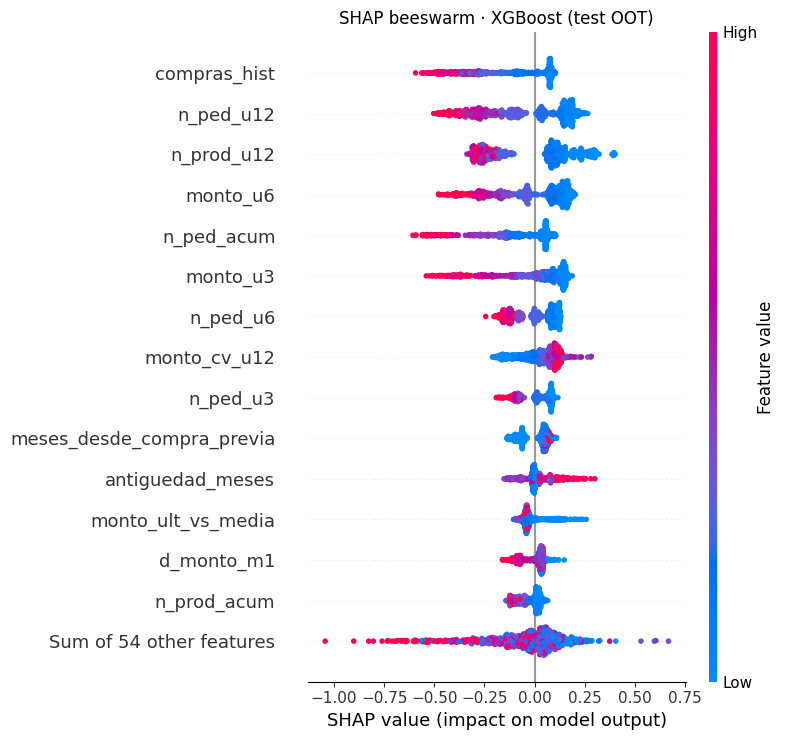

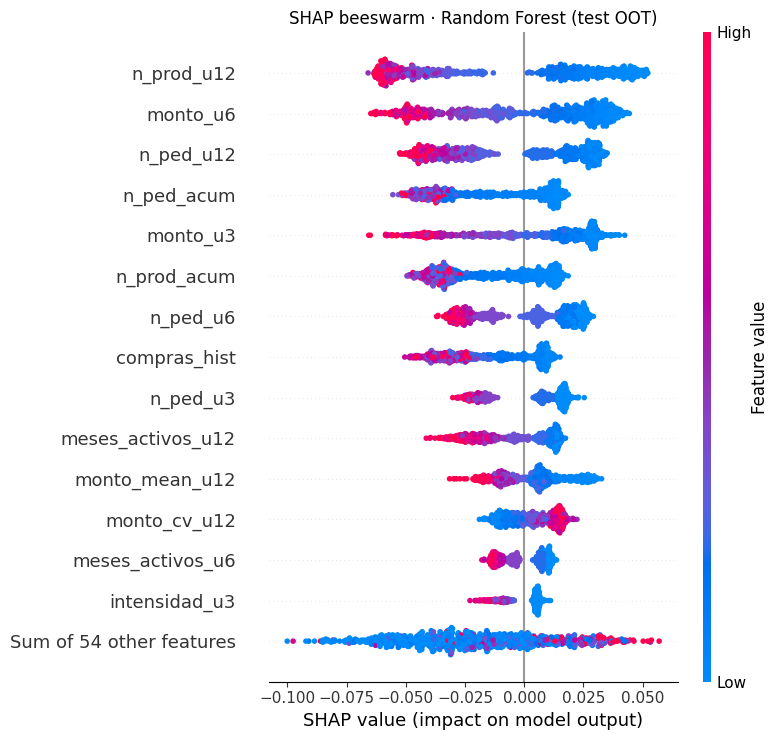

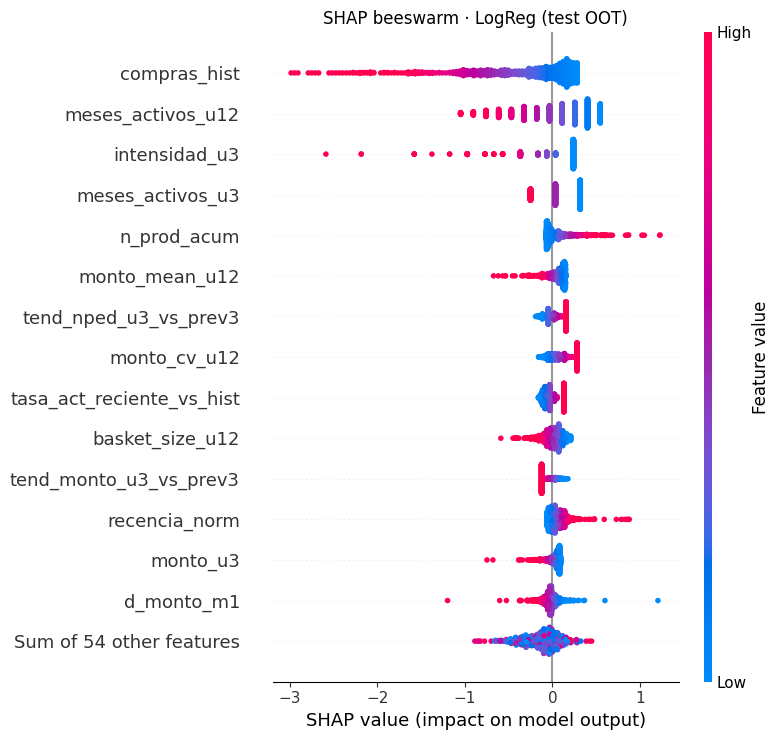

In [3]:
for l in LABELS:
    shap.plots.beeswarm(SV[l], max_display=15, show=False)
    plt.title(f"SHAP beeswarm · {l} (test OOT)")
    plt.tight_layout(); plt.show()

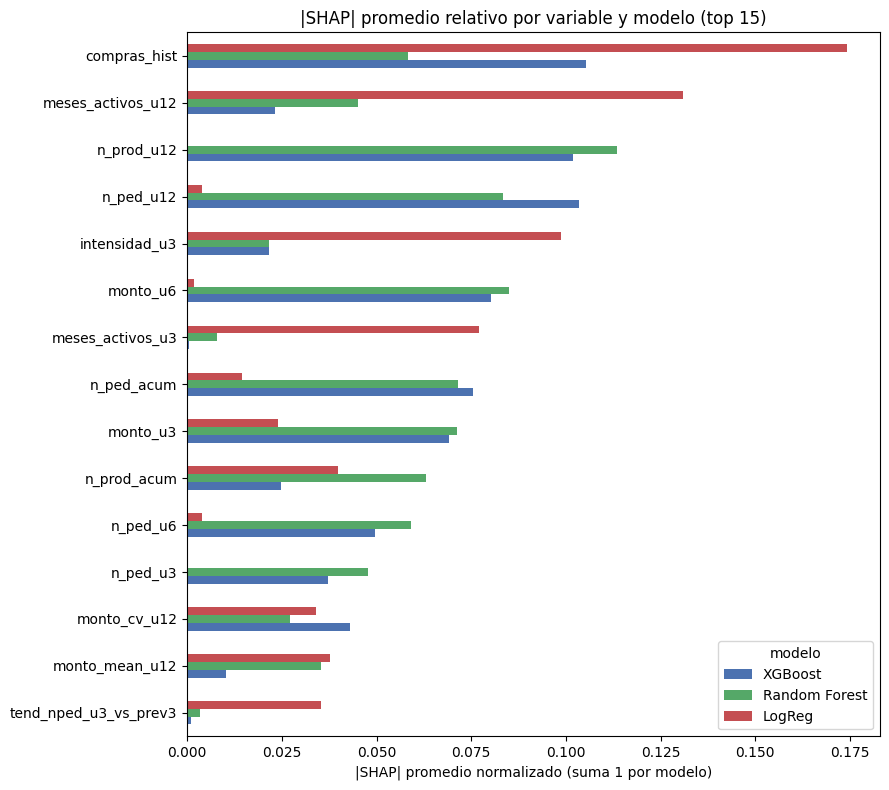

In [4]:
# |SHAP| promedio por variable y modelo, normalizado a peso relativo (suma 1)
mean_abs = pd.DataFrame({l: np.abs(SV[l].values).mean(0) for l in LABELS}, index=FEATS)
mean_abs_rel = mean_abs / mean_abs.sum()

top_idx = mean_abs_rel.max(axis=1).sort_values(ascending=False).head(15).index
top = mean_abs_rel.loc[top_idx].iloc[::-1]
ax = top.plot.barh(figsize=(9, 8), color=[COLOR[l] for l in LABELS])
ax.set_title("|SHAP| promedio relativo por variable y modelo (top 15)")
ax.set_xlabel("|SHAP| promedio normalizado (suma 1 por modelo)")
ax.legend(title="modelo")
plt.tight_layout(); plt.show()

## B · Dependencia: forma del efecto, comparada entre modelos

Tomamos la variable **más influyente en promedio** entre los tres modelos y graficamos
su aporte SHAP frente a su valor, en cada modelo. Esto revela la diferencia de fondo
entre familias: **LogReg** impone una **recta** (efecto lineal), mientras **XGBoost** y
**RF** pueden capturar **umbrales y saturación**. Si la forma de árbol es claramente no
lineal, hay señal que el modelo lineal no puede aprovechar (argumento a favor de los
árboles); si es casi recta, el LogReg no está dejando nada sobre la mesa.

Forma del efecto de 'compras_hist' (top |SHAP| promedio entre modelos):


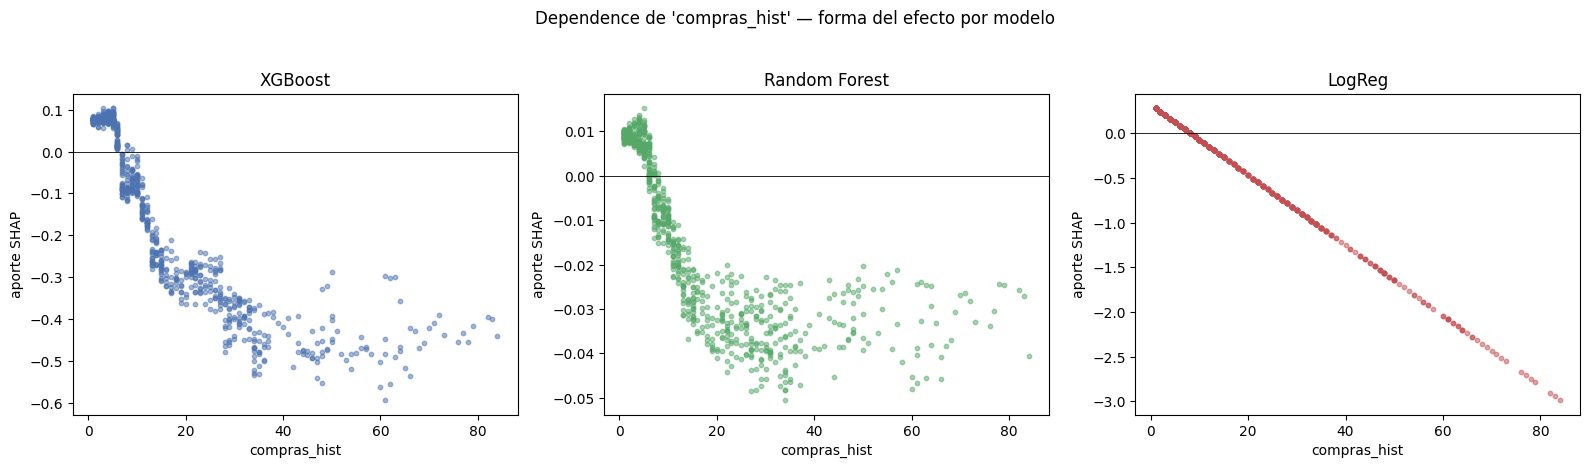

In [5]:
# variable más influyente en promedio entre los 3 modelos (peso relativo)
feat = mean_abs_rel.mean(axis=1).idxmax()
j = FEATS.index(feat)
print(f"Forma del efecto de '{feat}' (top |SHAP| promedio entre modelos):")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, l in zip(axes, LABELS):
    ax.scatter(SV[l].data[:, j], SV[l].values[:, j], s=10, alpha=0.5, color=COLOR[l])
    ax.axhline(0, color="k", lw=0.6)
    ax.set_title(l); ax.set_xlabel(feat); ax.set_ylabel("aporte SHAP")
fig.suptitle(f"Dependence de '{feat}' — forma del efecto por modelo", y=1.03)
plt.tight_layout(); plt.show()

## C · Explicación local: el mismo caso, los 3 modelos

`waterfall` descompone una predicción concreta: del valor base a la predicción final,
qué variable la empujó hacia churn y cuánto. Tomamos la vendedora de **mayor riesgo
promedio** entre los tres modelos y mostramos cómo la explica cada uno. Si los tres
señalan las mismas variables como motivo, el *porqué* es robusto → un mensaje de
retención bien fundamentado, independientemente del modelo que termine en producción.
(Recuerda: XGBoost y LogReg en log-odds, RF en probabilidad — compara qué variables
aparecen y con qué signo, no las magnitudes entre paneles.)

Caso (fila 95) · p(churn): XGBoost=0.852 | Random Forest=0.870 | LogReg=0.897 | real=1


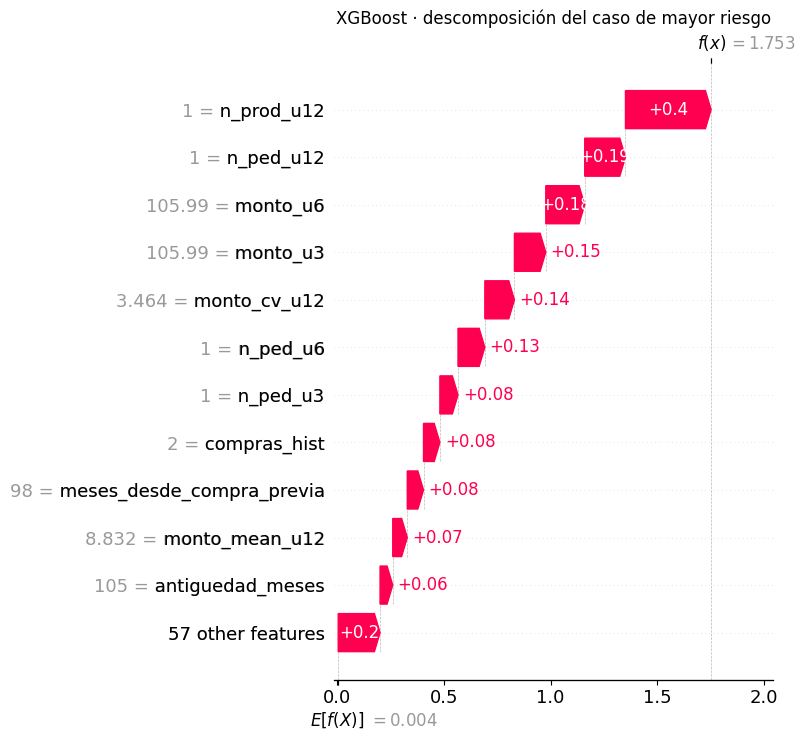

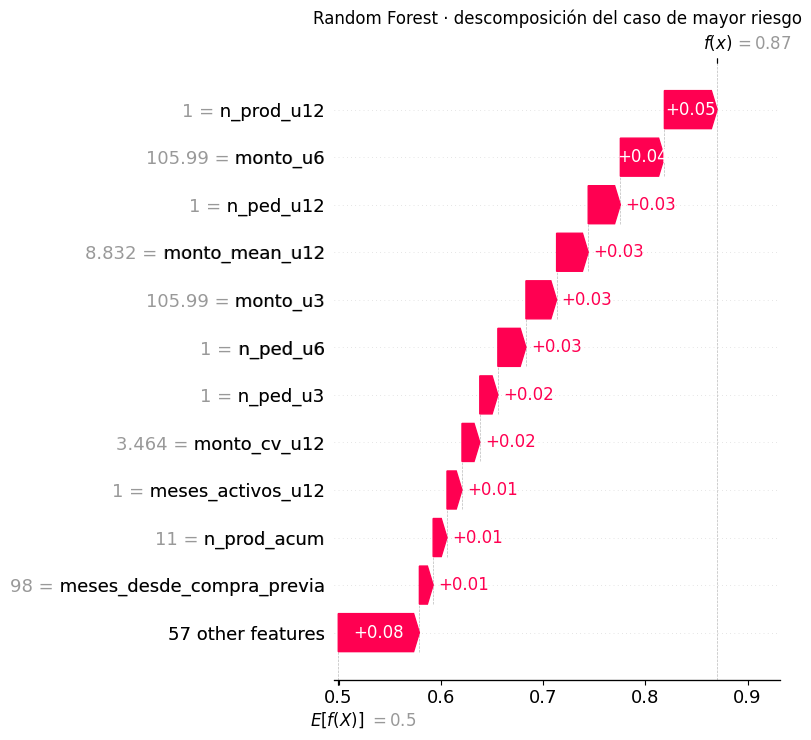

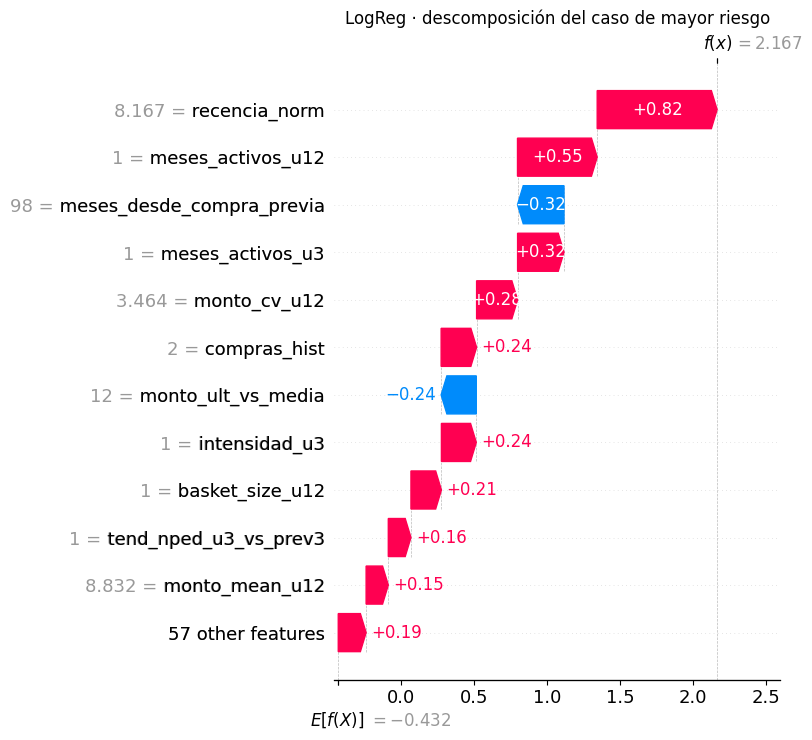

In [6]:
# caso de mayor riesgo promedio entre los 3 modelos
p_mean = np.mean([P[l] for l in LABELS], axis=0)
i = int(np.argmax(p_mean))
print(f"Caso (fila {i}) · p(churn): " +
      " | ".join(f"{l}={P[l][i]:.3f}" for l in LABELS) +
      f" | real={int(y_test[i])}")

for l in LABELS:
    shap.plots.waterfall(SV[l][i], max_display=12, show=False)
    plt.title(f"{l} · descomposición del caso de mayor riesgo")
    plt.tight_layout(); plt.show()

Caso (fila 296) · p(churn): XGBoost=0.012 | Random Forest=0.021 | LogReg=0.006 | real=0


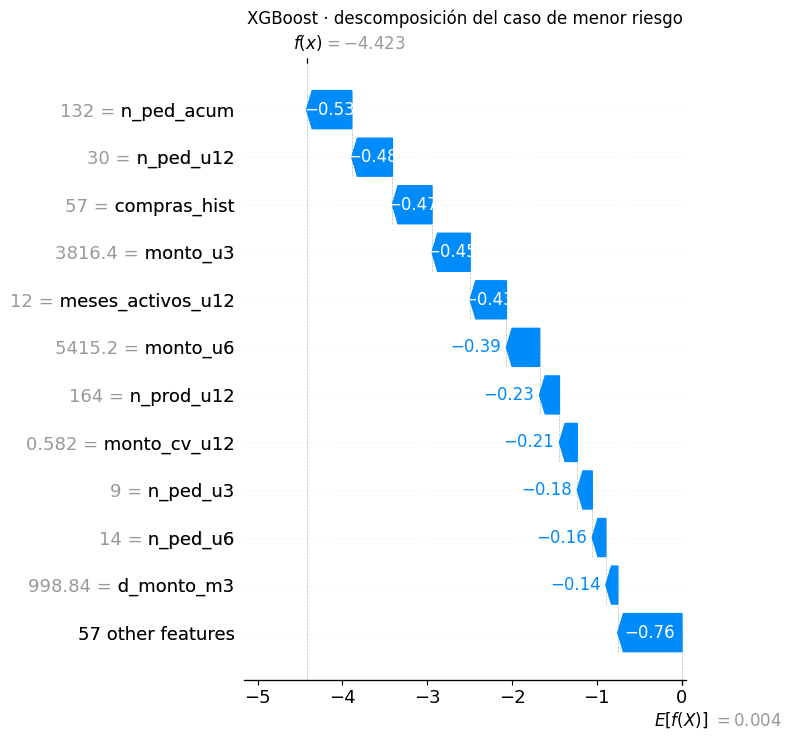

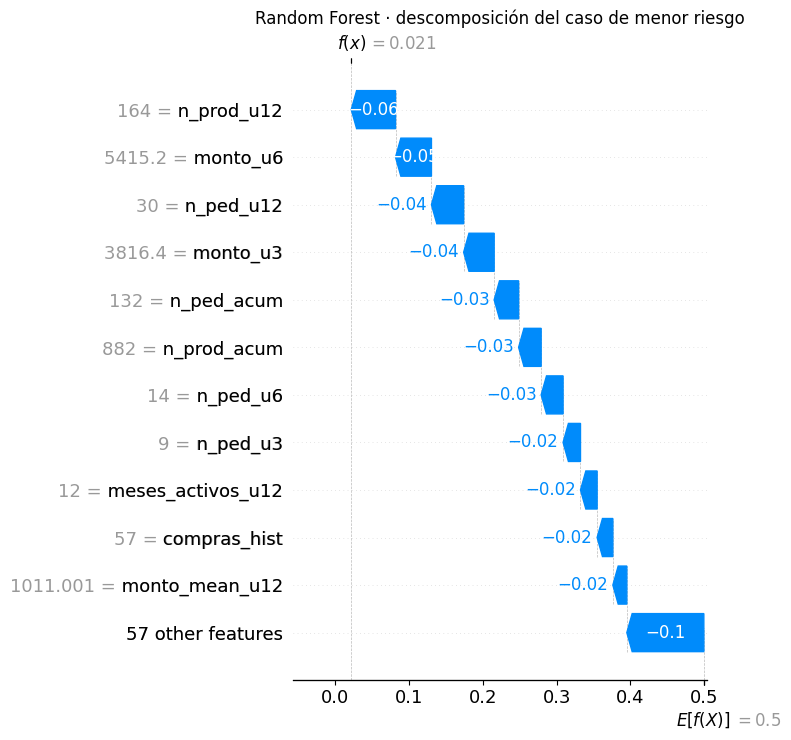

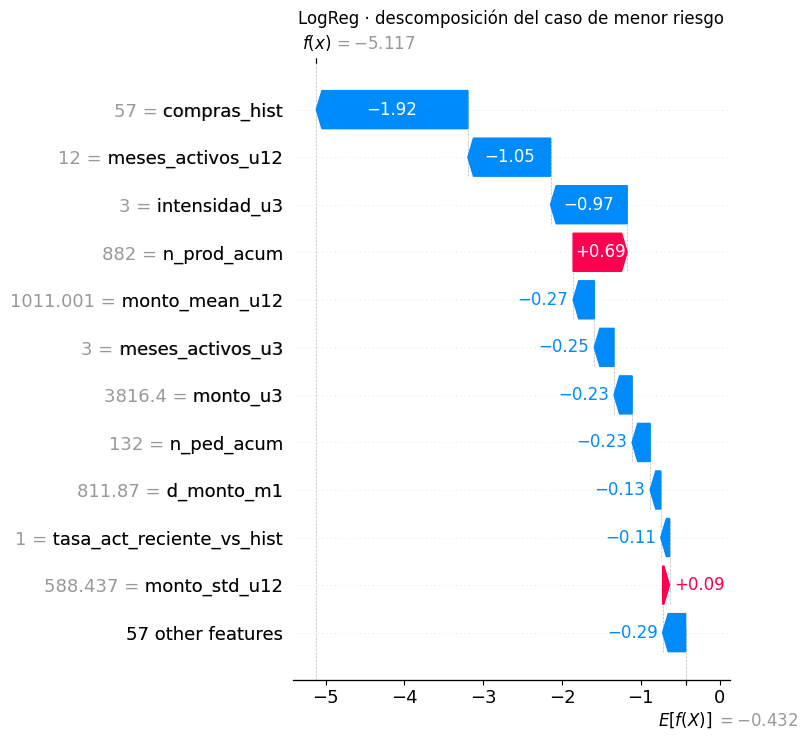

In [7]:
# caso de menor riesgo promedio entre los 3 modelos (contraste)
j_lo = int(np.argmin(p_mean))
print(f"Caso (fila {j_lo}) · p(churn): " +
      " | ".join(f"{l}={P[l][j_lo]:.3f}" for l in LABELS) +
      f" | real={int(y_test[j_lo])}")

for l in LABELS:
    shap.plots.waterfall(SV[l][j_lo], max_display=12, show=False)
    plt.title(f"{l} · descomposición del caso de menor riesgo")
    plt.tight_layout(); plt.show()

## D · Síntesis

El modelo final es **XGBoost** (elegido por Top Decil Lift en `03_utilidad_modelo`).
SHAP **respalda esa elección**: XGBoost explica el churn de forma coherente y
consistente con los otros dos modelos.

- **Dirección coherente y compartida**: los efectos tienen el signo que dicta el
  negocio, y los tres modelos coinciden. Mayor **recencia** (`meses_desde_compra_previa`,
  `recencia_norm`) → **más** churn; mayor **actividad/historia** (`compras_hist`,
  `meses_activos_u12`, `intensidad_u3`, `n_ped_u6`, `n_prod_u12`, `monto_u6`) →
  **menos** churn. Coincidencia en los tres = señal real, no artefacto del boosting.
- **Variable más influyente** (|SHAP| promedio entre modelos): **`compras_hist`** —
  la profundidad de la relación histórica de la vendedora es el factor de más peso,
  por encima incluso de la recencia pura.
- **Forma del efecto (sección B)**: el LogReg impone una recta por construcción,
  mientras XGBoost (y RF) pueden capturar no linealidad. En el panel de dependence de
  `compras_hist`, en la medida en que la nube de XGBoost se aparte de esa recta, hay
  señal no lineal que el modelo lineal no aprovecha → sustento técnico extra para la
  elección por TDL.
- **Casos locales robustos**: la vendedora de mayor riesgo (fila 95) recibe
  p(churn) ≈ 0.85–0.90 en los **tres** modelos (y efectivamente abandonó); la de
  menor riesgo (fila 296) ≈ 0.01–0.02 en los tres (y se mantuvo). El *porqué*
  individual es estable entre modelos → mensaje de retención bien fundamentado.

**Cierre de la evaluación**: con la Tabla 2 / Top Decil Lift (03), el acuerdo de
importancia (01) y la explicabilidad direccionalmente correcta y robusta (02),
**XGBoost** queda confirmado como modelo final — mejor targeting en el decil top y
señal interpretable.